In [9]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import sys
import numpy
from matplotlib.pyplot import figure, show, subplots
import numpy.ma as ma


datadir = "/net/virgo01/data/users/oassenberg/ObsAs/i"  #need to change this by uploading all treh data to my data folder 
 
#this sets the path that the program has to follow to get to our data!
path = Path(datadir)
filepaths_ = []
for filepath in path.iterdir():
    filepaths_.append(filepath)

filepaths = np.array(filepaths_)

filepaths.sort()
print(filepaths[0])
print(filepaths[-2])

#285 - 295 -> Biases 

#363 and 637 and 609 and 758 missing!
BIAS = []

for i in range(0, 10):
    BIAS.append(filepaths[i])
for i in range(798-289, 809-289):
    BIAS.append(filepaths[i])


DARK = []

for i in range(11, 17):
    DARK.append(filepaths[i])
for i in range(783-289, 796-289):
    DARK.append(filepaths[i])


FLATB = []

for i in range(303-285, 307-285):
    FLATB.append(filepaths[i])
for i in range(812-289, 814-289):
    FLATB.append(filepaths[i])


FLATV = []

for i in range(308-285, 312-285):
    FLATV.append(filepaths[i])
for i in range(815-289, 817-289):
    FLATV.append(filepaths[i])


FLATR = []

for i in range(314-285, 319-285):
    FLATR.append(filepaths[i])
for i in range(809-289, 811-289):
    FLATR.append(filepaths[i])


LIGHTR = []
LIGHTV = []
LIGHTB = []


for i in range(363-285, 604-286, 3):
    LIGHTR.append(filepaths[i])
for i in range(365-286, 604-286, 3):
    LIGHTV.append(filepaths[i])
for i in range(366-286, 604-286, 3):
    LIGHTB.append(filepaths[i])

for i in range(616-287, 636-287, 3):
    LIGHTR.append(filepaths[i])
for i in range(617-287, 636-287, 3):
    LIGHTV.append(filepaths[i])
for i in range(618-287, 636-287, 3):
    LIGHTB.append(filepaths[i])
    
for i in range(638-288, 758-289, 3):
    LIGHTR.append(filepaths[i])
for i in range(639-288, 758-289, 3):
    LIGHTV.append(filepaths[i])
for i in range(640-288, 758-289, 3):
    LIGHTB.append(filepaths[i])



GD336 = []
for i in range(759-289, 774-289):
    GD336.append(filepaths[i])

#Oli group is BV
#Grace group is VR

/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000285.Mouse_click_position.BIAS.FIT
/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000817.17h03m03.8s_69d55m49sN.FLAT.FIT


[PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000285.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000286.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000287.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000288.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000289.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000290.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000291.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000292.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000293.Mouse_click_position.BIAS.FIT'), PosixPath('/net/virgo01/data/users/o

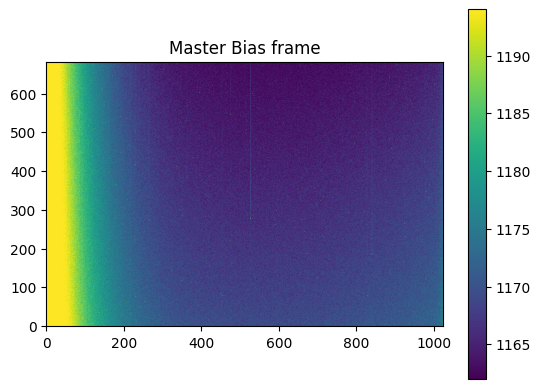

In [2]:
data_stack=[]
for file in BIAS:
    data_stack.append(fits.getdata(file))

masterBias = np.median(data_stack, axis=0)

print(BIAS)

fig, ax = subplots()
im=ax.imshow(masterBias, origin='lower', vmax=np.percentile(masterBias, 95), vmin=np.percentile(masterBias,5))
ax.set_title(f"Master Bias frame")
fig.colorbar(im)
show()

[PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000296.Mouse_click_position.DARK.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000297.Mouse_click_position.DARK.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000298.Mouse_click_position.DARK.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000299.Mouse_click_position.DARK.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000300.Mouse_click_position.DARK.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000301.Mouse_click_position.DARK.FIT')]


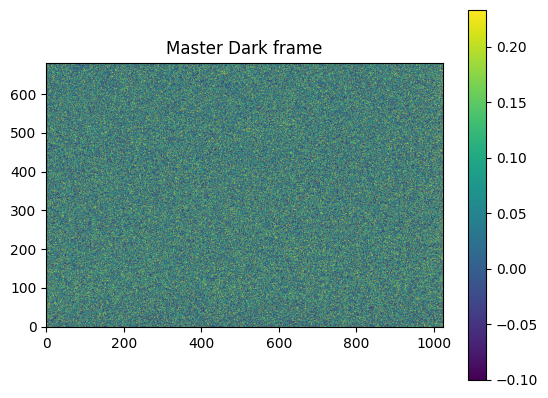

In [16]:
masterDark=[]
    
DARK30=[]
for i in range(11, 17):
    DARK30.append(filepaths[i])

print(DARK30)

datastackD=[]
for file in DARK:
    corr=((fits.getdata(file))-masterBias)/30
    datastackD.append(corr)

masterDark = np.median(datastackD, axis=0)

fig2, ax2 = subplots()
im2=ax2.imshow(masterDark, origin='lower', vmax=np.percentile(masterDark, 95), vmin=np.percentile(masterDark,5))
ax2.set_title(f"Master Dark frame")
fig2.colorbar(im2)
show()

13


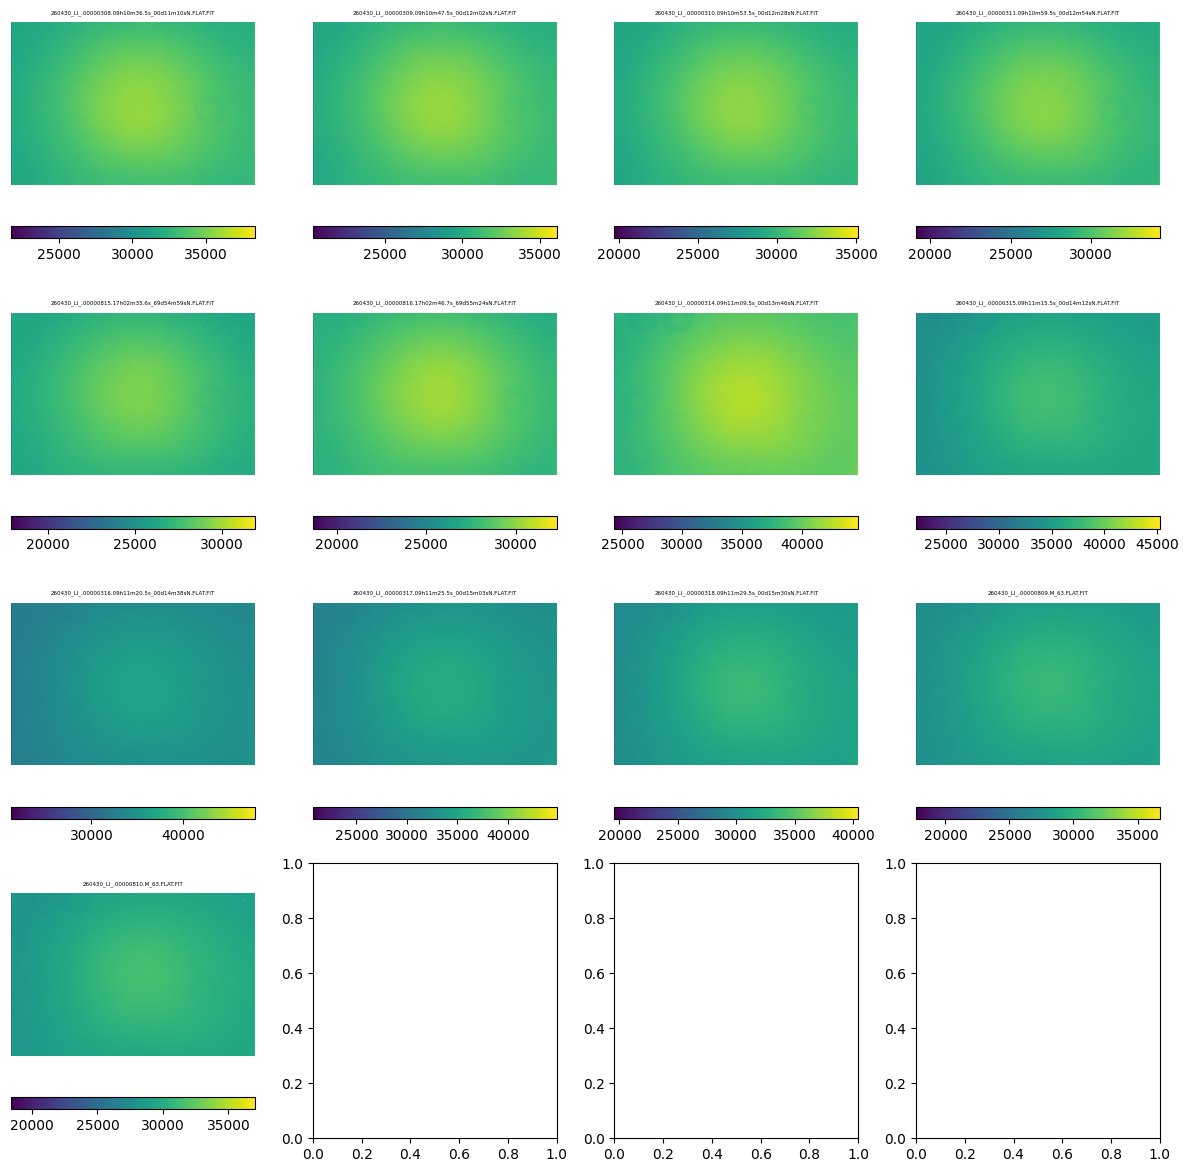

In [19]:
fig2, ax2 = subplots(4,4, figsize=(12, 12)) #showing all flatfields to sort through them

ax2=ax2.flatten()
FLATS=[]

FLATS.extend(FLATV)
FLATS.extend(FLATR)
print(len(FLATS))
for i, file in enumerate(FLATS): #making a mosaic
    im2=ax2[i].imshow(fits.getdata(file), origin='lower')
    ax2[i].set_title(f"{file.name}", fontsize=4) #displaying the file name so that I can know which ones to exclude
    ax2[i].set_axis_off() #turning off the axis to optimize space
    fig2.colorbar(im2, orientation="horizontal")
    fig2.tight_layout()
show()
#they all look good, none too over saturated, so i think we can keep all of them 

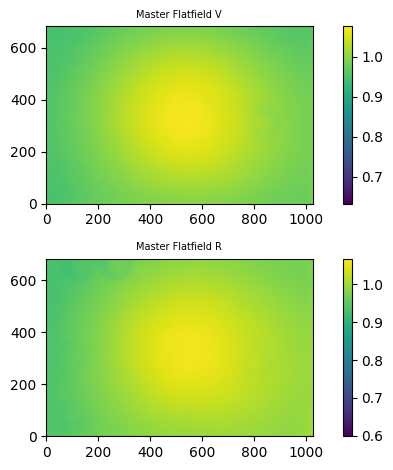

In [31]:
normaff_V=[]
for file in FLATV:
    corr=(fits.getdata(file))-masterBias-masterDark #subtracting the master bias frame
    divcorr1=corr/np.median(corr) #dividing by the median of the corrected file
    normaff_V.append(divcorr1)

normaff_R=[]
for file in FLATR:
    corr=(fits.getdata(file))-masterBias-masterDark #subtracting the master bias frame
    divcorr1=corr/np.median(corr) #dividing by the median of the corrected file
    normaff_R.append(divcorr1)


data_stackV=[] #using the same method to stack all of the frames   
for file in normaff_V:
    data_stackV.append(file)
    
masterFlatV= np.median(data_stackV, axis=0)

data_stackR=[] #using the same method to stack all of the frames   
for file in normaff_R:
    data_stackR.append(file)
    
masterFlatR= np.median(data_stackR, axis=0)

fig3, ax3 = subplots(2,1)


MASTERFLATS=[]

MASTERFLATS.append(masterFlatV)
MASTERFLATS.append(masterFlatR)

for i, file in enumerate(MASTERFLATS): #making a mosaic
    im3=ax3[i].imshow(file, origin='lower')
    ax3[0].set_title(f"Master Flatfield V", fontsize=7)
    ax3[1].set_title(f"Master Flatfield R", fontsize=7)
    fig3.colorbar(im3)
    fig3.tight_layout()